In [1]:
import torch as pt
from torch.nn.functional import one_hot
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pt.manual_seed(23004)

In [11]:
CODEBOOK_SIZE=256
EMBED_DIM=16
codebook = pt.zeros((CODEBOOK_SIZE, EMBED_DIM)).data.uniform_(-1/EMBED_DIM, 1/EMBED_DIM)
latent = pt.randn((32, 1, EMBED_DIM)).data.uniform_(-1/EMBED_DIM, 1/EMBED_DIM)

In [12]:
dist = latent.norm()**2 + codebook.norm(p=2,dim=-1)**2 - 2*latent@codebook.T

In [13]:
enc = one_hot(dist.argmax(-1), num_classes=CODEBOOK_SIZE)

<Axes: >

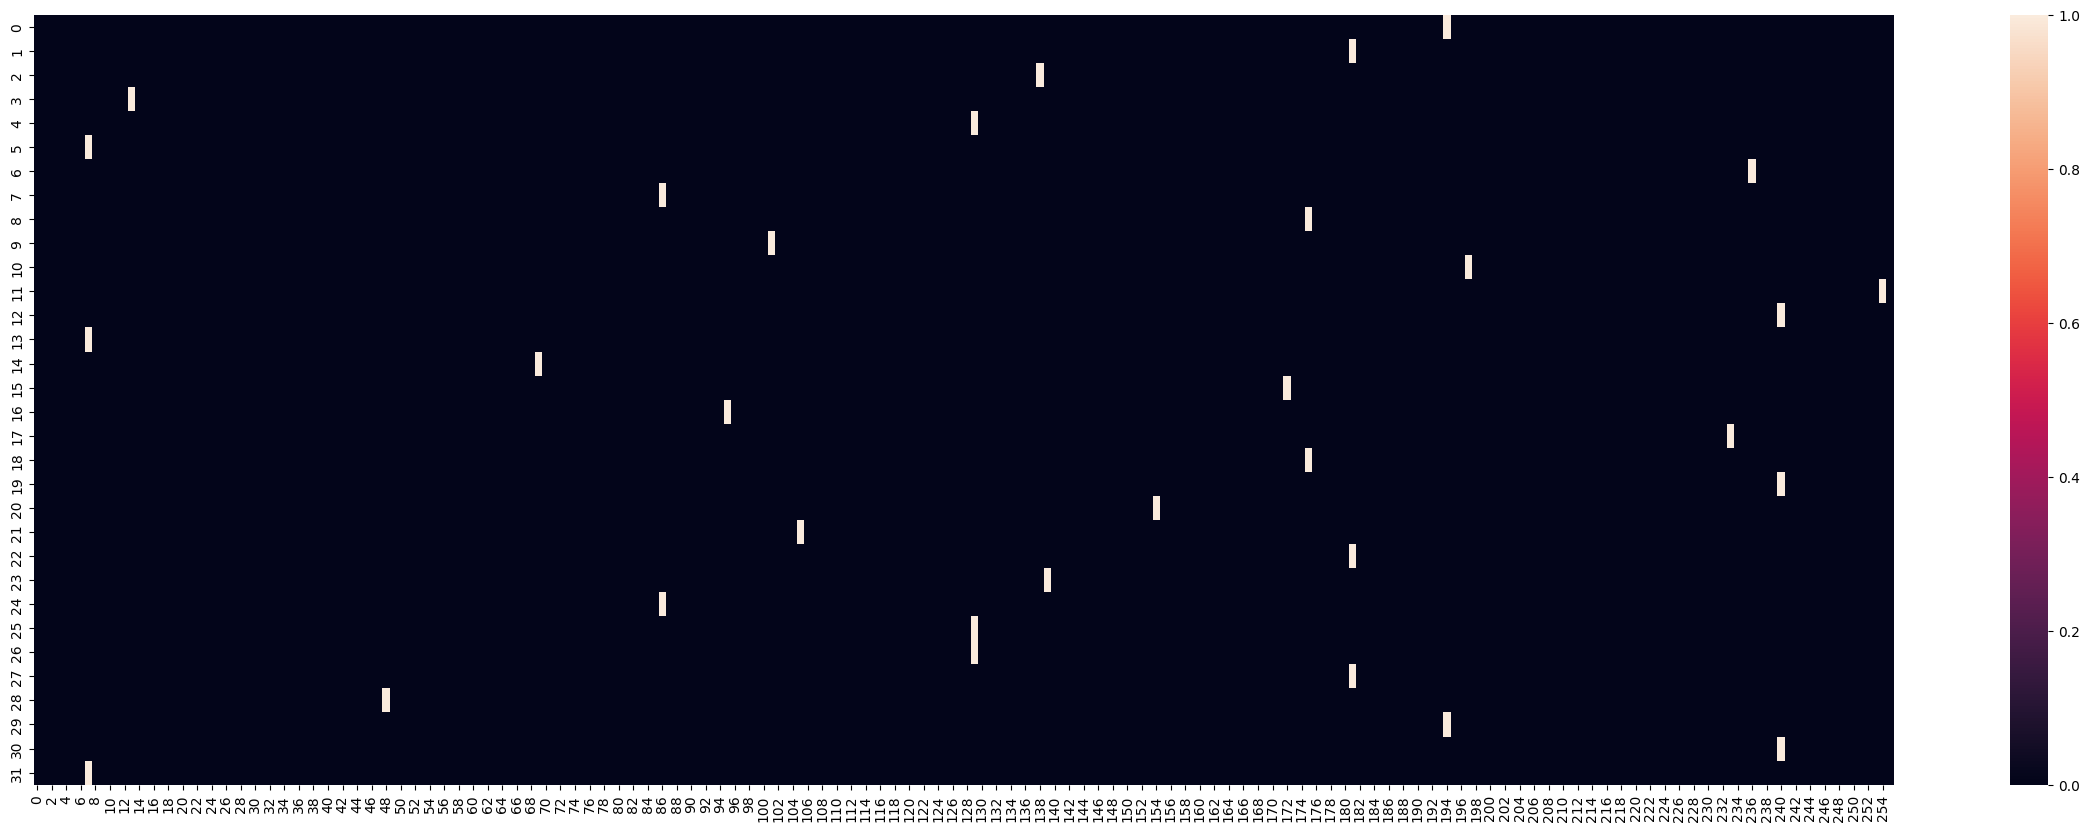

In [14]:
f = plt.figure(figsize=(30,10))
sns.heatmap(enc.squeeze(1))

In [22]:
gs = pt.nn.functional.gumbel_softmax(dist, tau=3, hard=False).squeeze(1)

<Axes: >

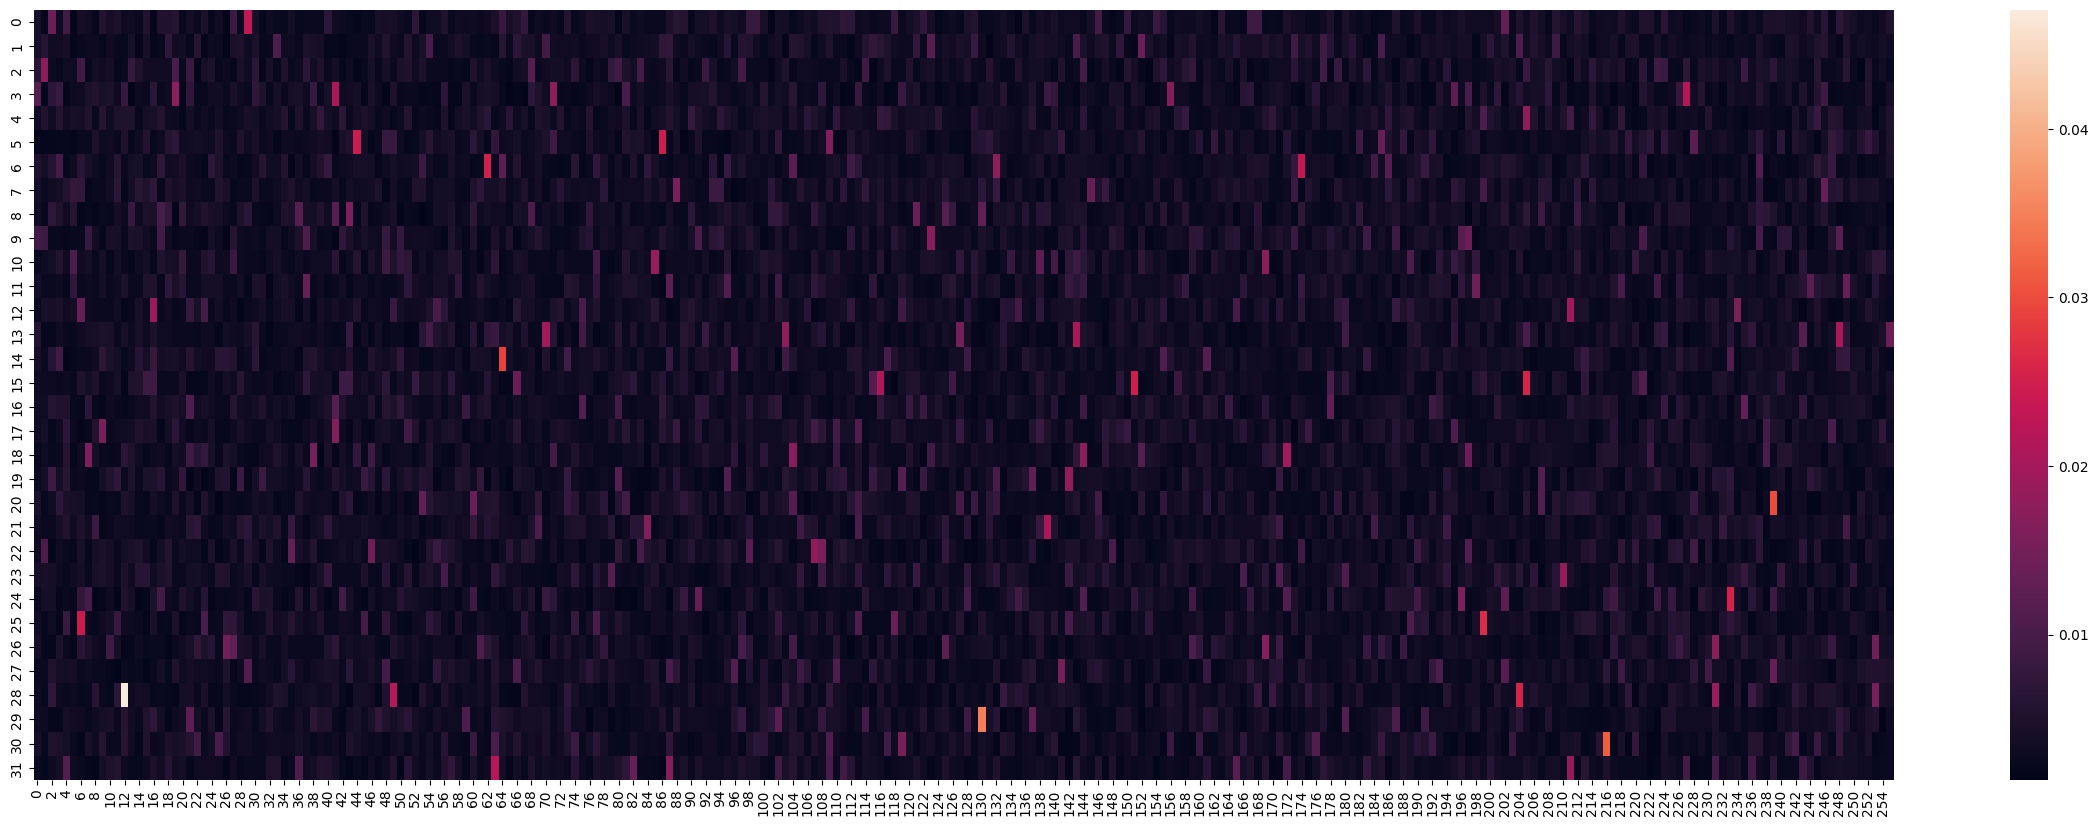

In [23]:
f = plt.figure(figsize=(30,10))
sns.heatmap(gs)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000])